In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import numpy as np

In [2]:
data_dir = 'data/fabric_patterns_reduced'  # Replace with the path to your main directory
img_height = 224
img_width = 224
batch_size = 32
epochs = 50  # Adjust as needed
validation_split = 0.2  # Percentage of data for validation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split  
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Assuming you have subdirectories for each class
    subset='training',
    shuffle=True,
    seed=42
)

Found 288 images belonging to 5 classes.


In [5]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 69 images belonging to 5 classes.


In [6]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
class_counts = np.bincount(train_generator.classes)
print(f"Class labels: {class_labels}")
print(f"Number of classes: {num_classes}")
print(f"Class counts: {class_counts}")

Class labels: ['Geometric_Abstract', 'Kids_Specific', 'Nature_Themed', 'Ornate_Traditional', 'Solid_Plain']
Number of classes: 5
Class counts: [ 56  13 189   7  23]


In [7]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [8]:
for layer in base_model.layers:
    layer.trainable = False

In [9]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
# x = Dropout(0.2)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [10]:
model = Model(inputs=base_model.input, outputs=predictions)

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # Adjust learning rate as needed
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,            # Stop after 10 epochs of no improvement
    min_delta=0.001,        # Minimum change to be considered an improvement
    mode='min',             # We want the validation loss to minimize
    verbose=1,              # Print a message when it stops
    restore_best_weights=True # Restore model weights from the epoch with the best val_loss
)

class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, accuracy_threshold=0.90, val_accuracy_threshold=0.90):
        super().__init__()
        self.accuracy_threshold = accuracy_threshold
        self.val_accuracy_threshold = val_accuracy_threshold
        print(f"Accuracy Threshold Callback initialized: Train Acc >= {accuracy_threshold*100}% OR Val Acc >= {val_accuracy_threshold*100}%")

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')

        if current_acc is None or current_val_acc is None:
            print("Warning: 'accuracy' or 'val_accuracy' not found in logs. Cannot check thresholds.")
            return

        if current_acc >= self.accuracy_threshold or current_val_acc >= self.val_accuracy_threshold:
            print(f"\nEpoch {epoch+1}: Reached desired accuracy threshold!")
            print(f"  Train Acc: {current_acc:.4f}, Val Acc: {current_val_acc:.4f}")
            self.model.stop_training = True

In [13]:
my_callbacks = [
    AccuracyThresholdCallback(accuracy_threshold=0.90, val_accuracy_threshold=0.90),
    early_stopping_callback
]

Accuracy Threshold Callback initialized: Train Acc >= 90.0% OR Val Acc >= 90.0%


In [14]:
history = model.fit(
    train_generator,
    # steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
    # validation_steps=validation_generator.samples // batch_size,  
    verbose=2,
    # class_weight=class_weights,
    callbacks=my_callbacks
)

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
9/9 - 40s - 4s/step - accuracy: 0.5625 - loss: 1.3013 - val_accuracy: 0.6812 - val_loss: 0.9522
Epoch 2/50
9/9 - 14s - 2s/step - accuracy: 0.6979 - loss: 0.8344 - val_accuracy: 0.8116 - val_loss: 0.6474
Epoch 3/50
9/9 - 14s - 2s/step - accuracy: 0.7778 - loss: 0.6689 - val_accuracy: 0.8116 - val_loss: 0.5888
Epoch 4/50
9/9 - 14s - 2s/step - accuracy: 0.8160 - loss: 0.5524 - val_accuracy: 0.8696 - val_loss: 0.5747
Epoch 5/50
9/9 - 14s - 2s/step - accuracy: 0.8194 - loss: 0.5292 - val_accuracy: 0.8261 - val_loss: 0.6010
Epoch 6/50
9/9 - 14s - 2s/step - accuracy: 0.8056 - loss: 0.5125 - val_accuracy: 0.8696 - val_loss: 0.5719
Epoch 7/50
9/9 - 15s - 2s/step - accuracy: 0.8438 - loss: 0.4359 - val_accuracy: 0.8406 - val_loss: 0.6295
Epoch 8/50
9/9 - 15s - 2s/step - accuracy: 0.8611 - loss: 0.4068 - val_accuracy: 0.8841 - val_loss: 0.5902
Epoch 9/50
9/9 - 15s - 2s/step - accuracy: 0.8472 - loss: 0.3905 - val_accuracy: 0.8696 - val_loss: 0.5753
Epoch 10/50
9/9 - 15s - 2s/step - acc

In [15]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7812 - loss: 0.7575
Validation Loss: 0.6459
Validation Accuracy: 0.8281


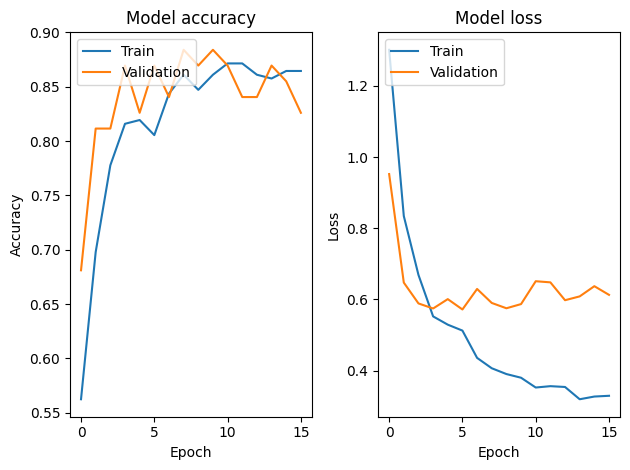

In [16]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [17]:
model.save('models/pattern_model_1.h5')

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
model_path = "models/pattern_model_1.h5"
model_1 = tf.keras.models.load_model(model_path)

In [19]:
# --- 3. Make Predictions on the Validation Set ---
print("Making predictions on the validation set...")
# Predict probabilities for each class
y_pred_probs = model_1.predict(validation_generator, steps=validation_generator.samples // batch_size + 1)
# Convert probabilities to class labels (index of the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the generator
# The generator provides labels in the order it processes the data
y_true = validation_generator.classes

Making predictions on the validation set...
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


In [20]:
class_names = list(validation_generator.class_indices.keys())
print("\n--- Classification Report ---")
# target_names: provides meaningful labels for the report
# digits: number of decimal places for floating point values
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


--- Classification Report ---
                    precision    recall  f1-score   support

Geometric_Abstract     0.8000    0.6154    0.6957        13
     Kids_Specific     0.0000    0.0000    0.0000         3
     Nature_Themed     0.8519    0.9787    0.9109        47
Ornate_Traditional     0.0000    0.0000    0.0000         1
       Solid_Plain     1.0000    1.0000    1.0000         5

          accuracy                         0.8551        69
         macro avg     0.5304    0.5188    0.5213        69
      weighted avg     0.8034    0.8551    0.8240        69



C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


--- Confusion Matrix ---
[[ 8  0  5  0  0]
 [ 1  0  2  0  0]
 [ 1  0 46  0  0]
 [ 0  0  1  0  0]
 [ 0  0  0  0  5]]


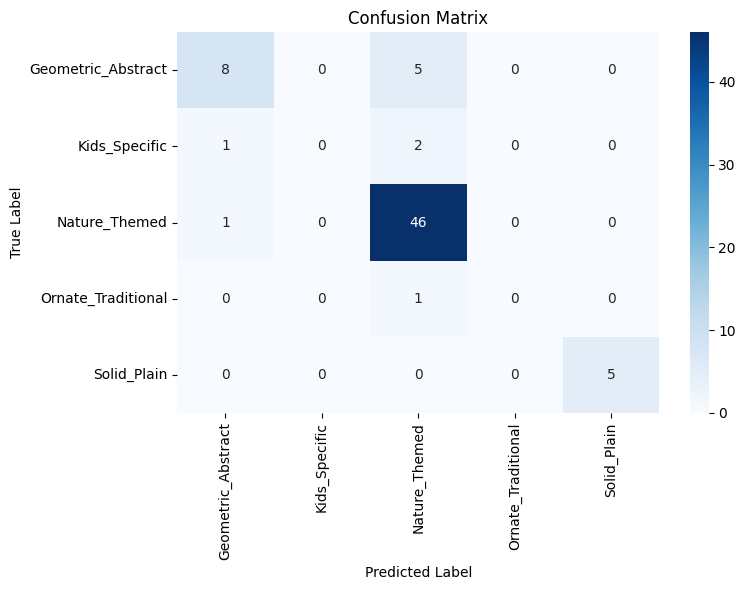

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()